# Lab 4 — Numerical Methods

**Course:** Programming and Numerical Methods for Economics (ECNM10115)
**University of Edinburgh**

**Purpose:** This lab teaches the numerical methods needed for
**Problem Set C**.  You will implement root-finding algorithms from scratch,
use SciPy's optimisation routines, and learn about fixed-point iteration
and constrained optimisation.

**Topics covered:**

1. Root-finding — bisection method
2. Root-finding — Newton's method
3. Using `scipy.optimize.fsolve`
4. Unconstrained optimisation — `minimize` with different methods
5. Constrained optimisation — bounds, equality and inequality constraints
6. Fixed-point iteration and convergence


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve, minimize


---
## 1. Root-finding — the bisection method

The **bisection method** finds a root of $f(x) = 0$ in an interval $[a, b]$
where $f(a)$ and $f(b)$ have opposite signs.  At each step, we halve the
interval.

**Algorithm:**
1. Compute $m = (a + b)/2$
2. If $f(a) \cdot f(m) < 0$: root is in $[a, m]$, so set $b = m$
3. Otherwise: root is in $[m, b]$, so set $a = m$
4. Repeat until $|b - a| < \text{tol}$

**Convergence:** The error halves each iteration → **linear** convergence.
After $n$ iterations, the error is at most $(b - a) / 2^n$.


### Worked example

In [2]:
def bisection(f, a, b, tol=1e-8, max_iter=100):
    """Find a root of f in [a, b] using the bisection method.
    Returns (root, history_of_midpoints).
    """
    assert f(a) * f(b) < 0, "f(a) and f(b) must have opposite signs"
    history = []
    for i in range(max_iter):
        m = (a + b) / 2
        history.append(m)
        if abs(f(m)) < tol or (b - a) / 2 < tol:
            return m, history
        if f(a) * f(m) < 0:
            b = m
        else:
            a = m
    return m, history

# Example: find the equilibrium price where supply = demand
# Demand: Q_d = 100 - 2P,  Supply: Q_s = 10 + 3P
# Excess demand: ED(P) = Q_d - Q_s = 90 - 5P = 0  →  P* = 18
excess_demand = lambda P: (100 - 2*P) - (10 + 3*P)

P_star, hist = bisection(excess_demand, 0, 50)
print(f"Equilibrium price: P* = {P_star:.6f}")
print(f"Iterations: {len(hist)}")
print(f"f(P*) = {excess_demand(P_star):.2e}")  # should be ≈ 0


Equilibrium price: P* = 18.000000
Iterations: 33
f(P*) = 3.49e-09


### ✏️ Exercise 1

The **Solow steady state** satisfies $s \cdot k^{\alpha} = (n + \delta) \cdot k$,
or equivalently $g(k) = s \cdot k^{\alpha} - (n + \delta) \cdot k = 0$.

Use $s = 0.3$, $\alpha = 0.33$, $n = 0.02$, $\delta = 0.05$.

1. Define $g(k)$ and plot it for $k \in [0.1, 20]$.
2. Use your `bisection` function to find $k^*$ in $[0.1, 20]$.
3. Verify against the analytical solution: $k^* = \left(\frac{s}{n + \delta}\right)^{1/(1-\alpha)}$.


In [3]:
# Your answer here


### Solution

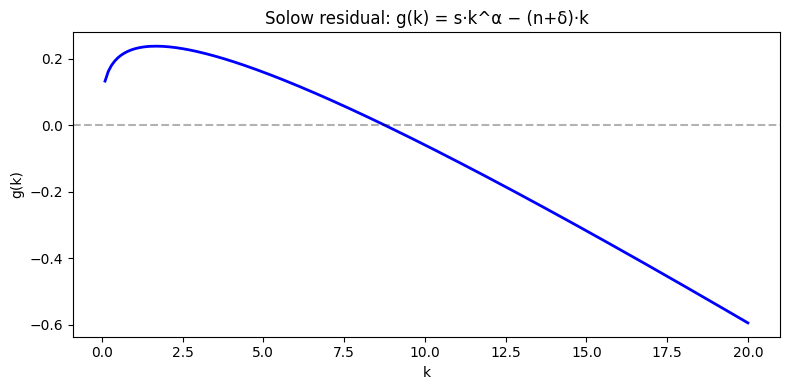

Bisection: k* = 8.776437, iterations = 26
Analytical: k* = 8.776437
Difference: 3.52e-08


In [4]:
# --- Solution ---
s, alpha, n, delta = 0.3, 0.33, 0.02, 0.05

def solow_residual(k):
    return s * k**alpha - (n + delta) * k

# 1. Plot
k_grid = np.linspace(0.1, 20, 200)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_grid, solow_residual(k_grid), 'b-', lw=2)
ax.axhline(0, color='k', ls='--', alpha=0.3)
ax.set_xlabel("k"); ax.set_ylabel("g(k)")
ax.set_title("Solow residual: g(k) = s·k^α − (n+δ)·k")
plt.tight_layout(); plt.show()

# 2. Bisection
k_star, hist = bisection(solow_residual, 0.1, 20)
print(f"Bisection: k* = {k_star:.6f}, iterations = {len(hist)}")

# 3. Analytical
k_analytical = (s / (n + delta))**(1 / (1 - alpha))
print(f"Analytical: k* = {k_analytical:.6f}")
print(f"Difference: {abs(k_star - k_analytical):.2e}")


---
## 2. Root-finding — Newton's method

Newton's method uses the derivative to converge much faster:

$$x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}$$

**Convergence:** **Quadratic** — the number of correct digits roughly doubles
each iteration.  But it requires $f'(x)$ and a good starting point.


### Worked example

IRR (Newton):    0.15238237  (5 iterations)
IRR (Bisection): 0.15238237  (26 iterations)


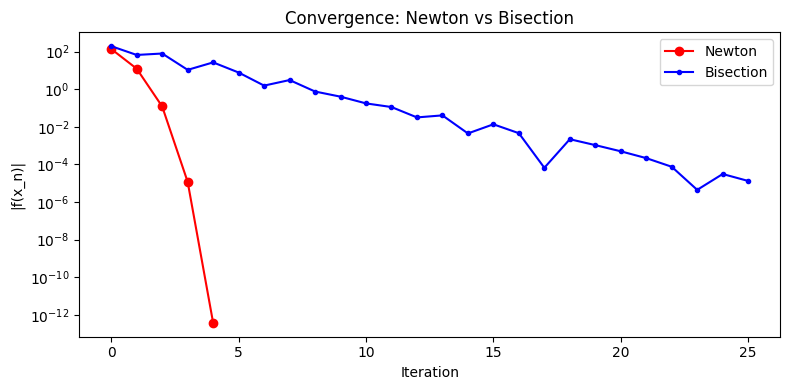

In [5]:
def newton(f, fprime, x0, tol=1e-10, max_iter=100):
    """Newton's method for f(x) = 0.
    Returns (root, history).
    """
    history = [x0]
    x = x0
    for i in range(max_iter):
        fx = f(x)
        if abs(fx) < tol:
            return x, history
        x = x - fx / fprime(x)
        history.append(x)
    return x, history

# Example: find the IRR of cash flows [-1000, 300, 300, 300, 300, 300]
cashflows = np.array([-1000, 300, 300, 300, 300, 300])
T = len(cashflows)

def npv(r):
    return sum(cashflows[t] / (1 + r)**t for t in range(T))

def npv_prime(r):
    return sum(-t * cashflows[t] / (1 + r)**(t + 1) for t in range(1, T))

irr, hist_newton = newton(npv, npv_prime, 0.1)
_, hist_bisect = bisection(npv, 0.001, 0.5)

print(f"IRR (Newton):    {irr:.8f}  ({len(hist_newton)} iterations)")
print(f"IRR (Bisection): {hist_bisect[-1]:.8f}  ({len(hist_bisect)} iterations)")

# Convergence comparison
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(range(len(hist_newton)), [abs(npv(x)) for x in hist_newton], 'ro-', label="Newton")
ax.semilogy(range(len(hist_bisect)), [abs(npv(x)) for x in hist_bisect], 'b.-', label="Bisection")
ax.set_xlabel("Iteration"); ax.set_ylabel("|f(x_n)|")
ax.set_title("Convergence: Newton vs Bisection"); ax.legend()
plt.tight_layout(); plt.show()


### ✏️ Exercise 2

Find the root of $f(x) = x^3 - 2x - 5$ near $x = 2$.

1. Compute $f'(x) = 3x^2 - 2$.
2. Apply Newton's method starting from $x_0 = 2$.
3. Apply the bisection method with $[1, 3]$.
4. Compare the number of iterations needed for tolerance $10^{-10}$.


In [6]:
# Your answer here


### Solution

In [7]:
# --- Solution ---
f = lambda x: x**3 - 2*x - 5
fp = lambda x: 3*x**2 - 2

# Newton
root_n, hist_n = newton(f, fp, 2.0, tol=1e-10)
print(f"Newton: root = {root_n:.10f}, iterations = {len(hist_n)}")

# Bisection
root_b, hist_b = bisection(f, 1, 3, tol=1e-10)
print(f"Bisection: root = {root_b:.10f}, iterations = {len(hist_b)}")

print(f"\nNewton converges in {len(hist_n)} iterations vs {len(hist_b)} for bisection.")
print("This illustrates quadratic vs linear convergence.")


Newton: root = 2.0945514815, iterations = 5
Bisection: root = 2.0945514815, iterations = 33

Newton converges in 5 iterations vs 33 for bisection.
This illustrates quadratic vs linear convergence.


---
## 3. Using `scipy.optimize.fsolve`

For practical root-finding, SciPy's `fsolve` wraps a robust hybrid method
(Powell's method + Newton).  It handles systems of equations too.

```python
from scipy.optimize import fsolve
root = fsolve(f, x0)                    # single equation
roots = fsolve(system, [x0, y0])        # system of equations
```


### Worked example

In [8]:
# Single equation
root = fsolve(lambda P: 90 - 5*P, 10)
print(f"Equilibrium price: {root[0]:.4f}")

# System of equations: IS-LM model
# IS: Y = C + I + G where C = 50 + 0.6(Y-100), I = 200 - 50r, G = 100
# LM: M/P = 0.5Y - 100r where M/P = 500

def is_lm(vars):
    Y, r = vars
    C = 50 + 0.6 * (Y - 100)
    I = 200 - 50 * r
    G = 100
    eq1 = C + I + G - Y            # IS equation
    eq2 = 0.5 * Y - 100 * r - 500  # LM equation
    return [eq1, eq2]

Y_star, r_star = fsolve(is_lm, [1000, 0.05])
print(f"\nIS-LM equilibrium: Y* = {Y_star:.2f}, r* = {r_star:.4f}")


Equilibrium price: 18.0000

IS-LM equilibrium: Y* = 830.77, r* = -0.8462


### ✏️ Exercise 3

The **IS curve** gives equilibrium output as a function of the interest rate:

$$Y^* = \frac{c_0 - c_1 T + I_0 - b r + G}{1 - c_1}$$

Use $c_0 = 50$, $c_1 = 0.6$, $I_0 = 200$, $b = 50$, $G = 100$, $T = 100$.

1. For $r = 0.05$, solve for $Y^*$ using `fsolve` and verify against the formula.
2. Compute $Y^*$ for $r \in [0, 0.15]$ (use `np.linspace` and a loop).
3. Plot the IS curve with $r$ on the vertical axis and $Y$ on the horizontal.


In [9]:
# Your answer here


### Solution

fsolve: Y* = 718.75
Formula: Y* = 718.75


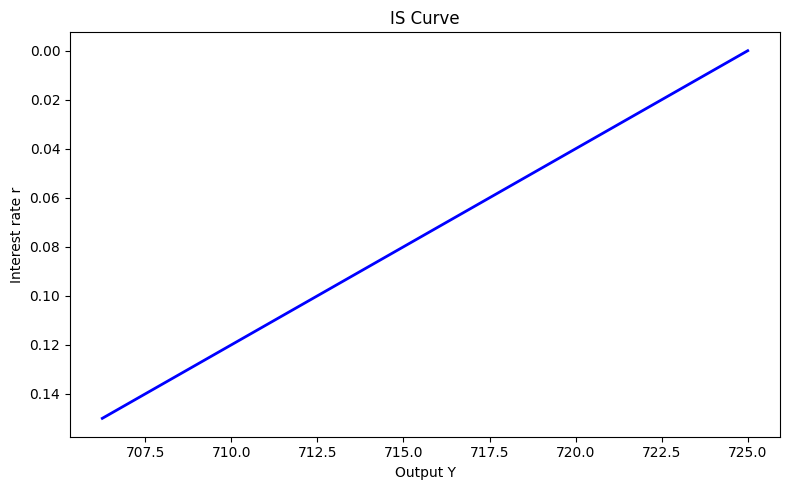

In [10]:
# --- Solution ---
c0, c1, I0, b, G, T = 50, 0.6, 200, 50, 100, 100

def IS_residual(Y, r):
    C = c0 + c1 * (Y - T)
    I = I0 - b * r
    return C + I + G - Y

# 1. Solve for r = 0.05
r_val = 0.05
Y_num = fsolve(lambda Y: IS_residual(Y, r_val), 1000)[0]
Y_formula = (c0 - c1*T + I0 - b*r_val + G) / (1 - c1)
print(f"fsolve: Y* = {Y_num:.2f}")
print(f"Formula: Y* = {Y_formula:.2f}")

# 2 & 3. IS curve
r_grid = np.linspace(0, 0.15, 50)
Y_grid = [fsolve(lambda Y: IS_residual(Y, r), 1000)[0] for r in r_grid]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(Y_grid, r_grid, 'b-', lw=2)
ax.set_xlabel("Output Y"); ax.set_ylabel("Interest rate r")
ax.set_title("IS Curve"); ax.invert_yaxis()
plt.tight_layout(); plt.show()


---
## 4. Unconstrained optimisation — `scipy.optimize.minimize`

SciPy's `minimize` finds the minimum of a function.  Key methods:

| Method | Uses derivative? | Best for |
|--------|-----------------|----------|
| `Nelder-Mead` | No | Noisy, non-smooth functions |
| `BFGS` | Yes (approximates) | Smooth, well-behaved functions |
| `CG` | Yes | Large problems |
| `L-BFGS-B` | Yes | Large problems with bounds |

```python
result = minimize(f, x0, method='BFGS')
print(result.x, result.fun, result.nfev)
```


### Worked example

Nelder-Mead : x* = [1.000005, 1.000007], f(x*) = 6.32e-10, nfev = 179


BFGS        : x* = [0.999996, 0.999992], f(x*) = 1.58e-11, nfev = 168
CG          : x* = [0.999995, 0.999991], f(x*) = 2.03e-11, nfev = 214


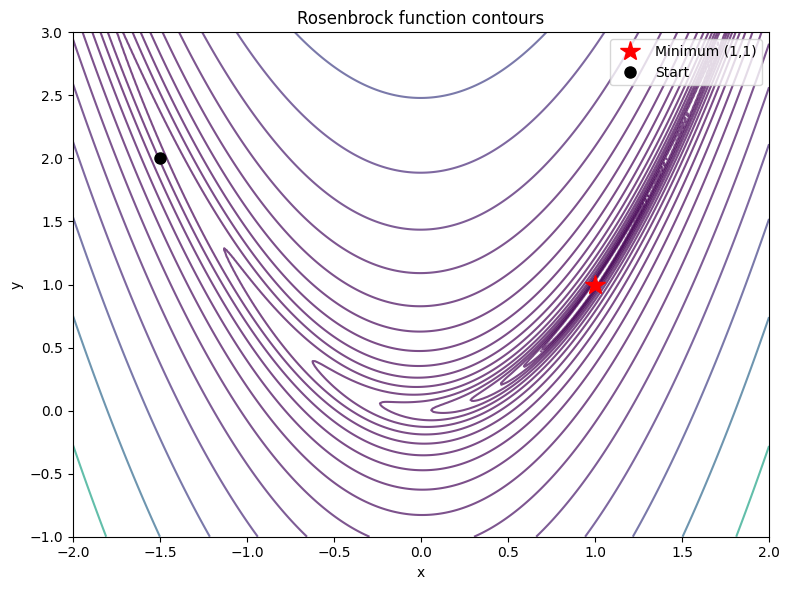

In [11]:
# Minimise the Rosenbrock function: f(x,y) = (1-x)^2 + 100(y-x^2)^2
def rosenbrock(xy):
    x, y = xy
    return (1 - x)**2 + 100 * (y - x**2)**2

x0 = np.array([-1.5, 2.0])

# Compare three methods
for method in ['Nelder-Mead', 'BFGS', 'CG']:
    res = minimize(rosenbrock, x0, method=method)
    print(f"{method:12s}: x* = [{res.x[0]:.6f}, {res.x[1]:.6f}], "
          f"f(x*) = {res.fun:.2e}, nfev = {res.nfev}")

# Contour plot
fig, ax = plt.subplots(figsize=(8, 6))
xx = np.linspace(-2, 2, 300)
yy = np.linspace(-1, 3, 300)
X, Y = np.meshgrid(xx, yy)
Z = (1 - X)**2 + 100 * (Y - X**2)**2

levels = np.logspace(-1, 3.5, 20)
ax.contour(X, Y, Z, levels=levels, cmap='viridis', alpha=0.7)
ax.plot(1, 1, 'r*', markersize=15, label='Minimum (1,1)')
ax.plot(x0[0], x0[1], 'ko', markersize=8, label='Start')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Rosenbrock function contours'); ax.legend()
plt.tight_layout(); plt.show()


### ✏️ Exercise 4

Minimise the **Booth function**: $f(x, y) = (x + 2y - 7)^2 + (2x + y - 5)^2$.

The minimum is at $(1, 3)$ where $f = 0$.

1. Define the function and minimise with `BFGS` starting from $(0, 0)$.
2. Use the `callback` argument to track $f$ at each iteration.
3. How many iterations does BFGS need?


In [12]:
# Your answer here


### Solution

x* = [1. 3.], f(x*) = 3.06e-16
Iterations: 7


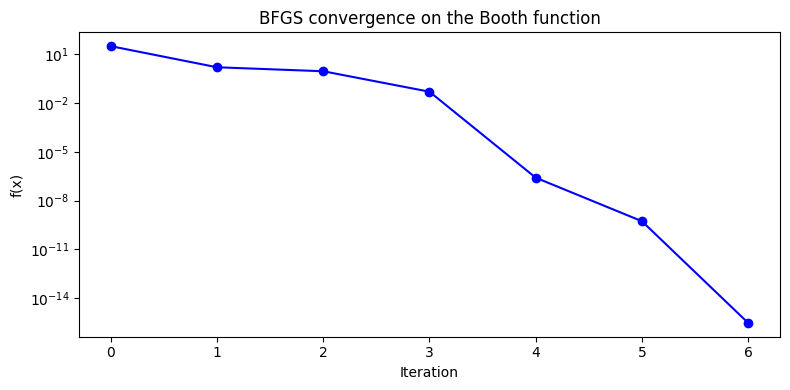

In [13]:
# --- Solution ---
def booth(xy):
    x, y = xy
    return (x + 2*y - 7)**2 + (2*x + y - 5)**2

# Track convergence
history = []
def callback(xk):
    history.append(booth(xk))

res = minimize(booth, [0, 0], method='BFGS', callback=callback)
print(f"x* = {res.x}, f(x*) = {res.fun:.2e}")
print(f"Iterations: {len(history)}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(range(len(history)), history, 'bo-')
ax.set_xlabel("Iteration"); ax.set_ylabel("f(x)")
ax.set_title("BFGS convergence on the Booth function")
plt.tight_layout(); plt.show()


---
## 5. Constrained optimisation — bounds and constraints

Many economic problems have constraints:

- **Bounds:** $0 \leq w_i \leq 1$ (portfolio weights)
- **Equality constraint:** $\sum w_i = 1$ (weights sum to 1)
- **Inequality constraint:** $r_p \geq r_{\min}$ (minimum return)

Use `method='SLSQP'` with the `bounds` and `constraints` arguments.

```python
bounds = [(0, 1)] * n                                  # n variables, each in [0,1]
constraints = [
    {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},   # equality
    {'type': 'ineq', 'fun': lambda w: w @ mu - 0.08}   # inequality (≥ 0)
]
result = minimize(objective, x0, method='SLSQP', bounds=bounds, constraints=constraints)
```


### Worked example

In [14]:
# Consumer utility maximisation
# max U = x1^0.4 * x2^0.6  subject to 2*x1 + 3*x2 = 120
alpha = 0.4
p1, p2, m = 2, 3, 120

# Negative utility (because minimize minimises)
neg_utility = lambda x: -(x[0]**alpha * x[1]**(1 - alpha))

# Budget constraint: p1*x1 + p2*x2 - m = 0
budget = {'type': 'eq', 'fun': lambda x: p1*x[0] + p2*x[1] - m}

# Bounds: quantities must be positive
bounds = [(0.01, None), (0.01, None)]

res = minimize(neg_utility, [10, 10], method='SLSQP',
               bounds=bounds, constraints=[budget])

x1_star, x2_star = res.x
print(f"Optimal bundle: x1* = {x1_star:.2f}, x2* = {x2_star:.2f}")
print(f"Utility: {-res.fun:.4f}")

# Analytical solution for Cobb-Douglas
x1_analytical = alpha * m / p1
x2_analytical = (1 - alpha) * m / p2
print(f"\nAnalytical: x1* = {x1_analytical:.2f}, x2* = {x2_analytical:.2f}")
print(f"Match: {np.allclose(res.x, [x1_analytical, x2_analytical], atol=0.01)}")


Optimal bundle: x1* = 24.00, x2* = 24.00
Utility: 24.0000

Analytical: x1* = 24.00, x2* = 24.00
Match: True


### ✏️ Exercise 5

A portfolio has 3 assets with expected returns $\mu = [0.12, 0.08, 0.04]$
and covariance matrix:

$$\Sigma = \begin{pmatrix} 0.04 & 0.01 & 0.00 \\ 0.01 & 0.02 & 0.005 \\ 0.00 & 0.005 & 0.01 \end{pmatrix}$$

Find the minimum-variance portfolio subject to:
- Weights sum to 1
- Each weight is between 0 and 1
- Expected return $\geq 0.07$


In [15]:
# Your answer here


### Solution

In [16]:
# --- Solution ---
mu = np.array([0.12, 0.08, 0.04])
Sigma = np.array([[0.04, 0.01, 0.00],
                   [0.01, 0.02, 0.005],
                   [0.00, 0.005, 0.01]])

port_var = lambda w: w @ Sigma @ w
bounds = [(0, 1)] * 3
constraints = [
    {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
    {'type': 'ineq', 'fun': lambda w: w @ mu - 0.07}
]

res = minimize(port_var, [1/3, 1/3, 1/3], method='SLSQP',
               bounds=bounds, constraints=constraints)

print(f"Optimal weights: {np.round(res.x, 4)}")
print(f"Portfolio std dev: {np.sqrt(res.fun):.4f}")
print(f"Expected return: {res.x @ mu:.4f}")


Optimal weights: [0.2679 0.2143 0.5179]
Portfolio std dev: 0.0934
Expected return: 0.0700


---
## 6. Fixed-point iteration

**Fixed-point iteration** solves $x = g(x)$ by the recursion
$x_{n+1} = g(x_n)$.

The **Banach contraction mapping theorem** guarantees convergence when
$|g'(x^*)| < 1$ near the fixed point.

This is the foundation of **value function iteration** in dynamic
programming — a central method in macroeconomics (Week 8).


### Worked example

Convergent case: P* = 1.600000, iterations = 52
|g'(P*)| = 0.6667 < 1 ✓


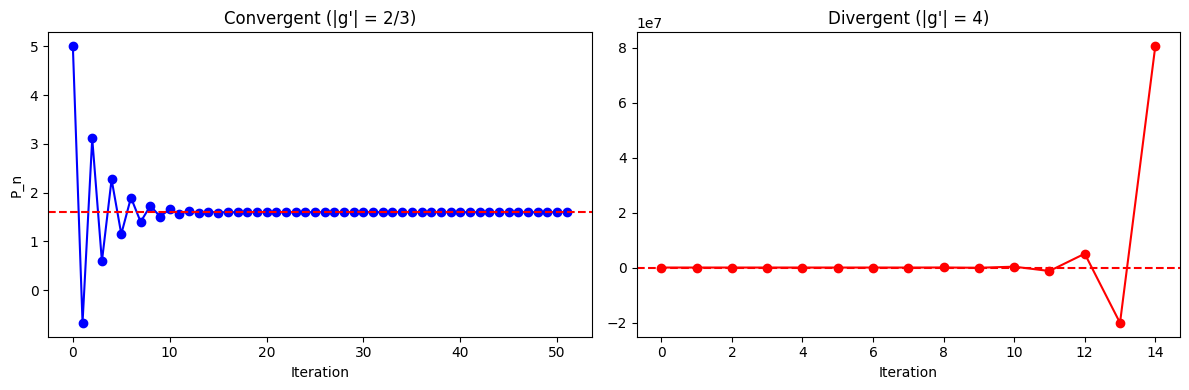

In [17]:
def fixed_point(g, x0, tol=1e-8, max_iter=500):
    """Fixed-point iteration: x = g(x).
    Returns (root, history).
    """
    history = [x0]
    x = x0
    for i in range(max_iter):
        x_new = g(x)
        history.append(x_new)
        if abs(x_new - x) < tol:
            return x_new, history
        x = x_new
    print("Warning: did not converge")
    return x, history

# Cobweb model: Qd = 10 - 2P, Qs = 2 + 3P
# Setting Qs(Pt) = Qd(Pt+1): P_{t+1} = (8 - 3Pt) / 2  ... wait
# Actually: Qd(P_{t+1}) = Qs(P_t) → 10 - 2*P_{t+1} = 2 + 3*P_t
# P_{t+1} = (8 - 3*P_t) / 2  → |g'| = 3/2 > 1  (diverges!)

# Corrected: Qs = 2 + 3P_t,  Qd = 10 - 2P_{t+1}
# P_{t+1} = (10 - Qs(P_t)) / 2 = (10 - 2 - 3P_t) / 2 = (8 - 3P_t) / 2
# g'(P) = -3/2 → |g'| = 1.5 > 1 → diverges

# Let's use a convergent example: P_{t+1} = (8 - 2P_t) / 3
# This comes from Qs = 2 + 2P, Qd = 10 - 3P
# g'(P) = -2/3 → |g'| = 2/3 < 1 → converges!
g_converge = lambda P: (8 - 2*P) / 3
P_star_c, hist_c = fixed_point(g_converge, 5.0)
print(f"Convergent case: P* = {P_star_c:.6f}, iterations = {len(hist_c)}")
print(f"|g'(P*)| = {2/3:.4f} < 1 ✓")

# Divergent case
g_diverge = lambda P: 16 - 4*P
_, hist_d = fixed_point(g_diverge, 3.5, max_iter=20)

# Plot both
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist_c, 'bo-'); axes[0].axhline(P_star_c, color='r', ls='--')
axes[0].set_title("Convergent (|g'| = 2/3)"); axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("P_n")

axes[1].plot(hist_d[:15], 'ro-'); axes[1].axhline(16/5, color='r', ls='--')
axes[1].set_title("Divergent (|g'| = 4)"); axes[1].set_xlabel("Iteration")
plt.tight_layout(); plt.show()


### ✏️ Exercise 6

The equation $x = \cos(x)$ has a fixed point near $x \approx 0.739$.

1. Use your `fixed_point` function starting from $x_0 = 0.5$.
2. How many iterations does it take?
3. Compute $|g'(x^*)| = |{-}\sin(x^*)|$ — is the convergence condition satisfied?
4. Try starting from $x_0 = 10$.  Does it still converge?  Why?


In [18]:
# Your answer here


### Solution

In [19]:
# --- Solution ---
x_star, hist = fixed_point(np.cos, 0.5)
print(f"Fixed point: x* = {x_star:.8f}")
print(f"Iterations: {len(hist)}")
print(f"|g'(x*)| = |sin(x*)| = {abs(np.sin(x_star)):.4f} < 1 ✓")

# Starting from x0 = 10
x_star2, hist2 = fixed_point(np.cos, 10.0)
print(f"\nFrom x0=10: x* = {x_star2:.8f}, iterations = {len(hist2)}")
print("It still converges because cos(x) ∈ [-1,1] for all x,")
print("so after one iteration we're already in a region where |g'| < 1.")


Fixed point: x* = 0.73908514
Iterations: 46
|g'(x*)| = |sin(x*)| = 0.6736 < 1 ✓

From x0=10: x* = 0.73908514, iterations = 46
It still converges because cos(x) ∈ [-1,1] for all x,
so after one iteration we're already in a region where |g'| < 1.


---
## Summary

You now have the numerical methods toolkit for **Problem Set C**:

| Concept | PS C Questions |
|---------|---------------|
| Bisection method | Q1, Q6(c), Q7(c) |
| Newton's method | Q7 |
| `fsolve` for equations and systems | Q1, Q2, Q5, Q10 |
| Unconstrained optimisation (`minimize`) | Q3, Q6 |
| Constrained optimisation (SLSQP) | Q4, Q8 |
| Fixed-point iteration | Q9 |
| Combining everything | Q10 (general equilibrium) |

Head to Problem Set C and put these methods to work!
